# 🧬 phyloDCA — Coevolution-Aware Ancestral Sequence Reconstruction

This notebook recovers **ancestral protein sequences** using phylogenetic ancestral state reconstruction (ASR) combined with **Direct Coupling Analysis (DCA)** — preserving the residue–residue couplings that shape real protein structure, stability, and function.

📄 *Towards coevolution-aware ancestral sequence reconstruction* — [bioRxiv preprint](https://www.biorxiv.org/content/10.64898/2026.06.08.731024v1)

**How to use this notebook**
1. Edit the configuration cell below with your dataset's file names.
2. Run every cell from top to bottom.
3. Find your ranked candidate ancestors in `output_<dataset>_candidates/`.

Everything needed — code (`utils/`), example data (`data_betaLac/`), and this notebook — ships with the repository, so there is nothing extra to download. See [`DOCUMENTATION.md`](DOCUMENTATION.md) for the full API reference.

## ⚙️ Step 1 — Configuration

Set your dataset name and file paths here. This is usually the **only cell you need to edit**.

In [1]:
PROJECT_ROOT = '/home/alya/phyloDCA_public/'
DATASET_NAME = 'betaLac'  # Change this for different datasets

# File names (these should exist in data_betaLac/extant_msa/)
MSA_FILENAME = 'PF13354_noinsert_max19gaps_nodupl_noclose_BetaLact.faa'

# File names (these should exist in data_betaLac/)
PARAMS_FILENAME = 'Parameters_conv_Matteo_pc_BetaLact.dat'

# Sampling parameters
NUM_SAMPLES = 1000  # How many sequences to sample from posterior
NUM_TOP_CANDIDATES = 10  # How many best ones to keep
MCMC_TEMPERATURE = 0.2  # 0-1, lower = more coevolution signal
print("✓ Configuration loaded")

✓ Configuration loaded


## 📦 Step 2 — Imports & Setup

Loads the `phyloDCA` helper functions and creates the output folders for this dataset.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Add project to path
sys.path.insert(0, PROJECT_ROOT)

# Import helpers
from utils import *

# Setup all paths
paths = setup_paths(PROJECT_ROOT, DATASET_NAME)
print(f"\nProject structure:")
print(f"  Data directory: {paths['data']}")
print(f"  Output ASR: {paths['output_asr']}")
print(f"  Output candidates: {paths['output_candidates']}")

Folder 'gradient_figs/' already exists.
✓ Paths configured and output directories created

Project structure:
  Data directory: /home/alya/phyloDCA_public/data_betaLac/
  Output ASR: /home/alya/phyloDCA_public/output_betaLac_asr/
  Output candidates: /home/alya/phyloDCA_public/output_betaLac_candidates/


### 💡 Optional — Install dependencies

If any import above failed, uncomment the relevant line(s) below and run this cell once.

In [3]:
# Uncomment any line below to install a missing dependency
# !pip install --upgrade pip
# !pip install ete3
# !pip install matplotlib
# !pip install biopython
# !pip install seaborn
# !pip install pandas
# !pip install hmmer
# !pip install distinctipy
# !pip install torch
# !pip install tqdm
# !pip install fasttree
# !pip install scikit-learn
# !pip install numba

## 📂 Step 3 — Load Data

Loads the extant multiple sequence alignment (MSA) and the fitted DCA (Potts) parameters for your protein family.

In [4]:
msa_file = f"{paths['msa']}{MSA_FILENAME}"
params_file = f"{paths['data']}{PARAMS_FILENAME}"

msa_array, headers, fields, couplings = load_data(msa_file, params_file)
print(f"\nData summary:")
print(f"  MSA: {len(headers)} sequences × {msa_array.shape[1]} sites")
print(f"  DCA model ready")

Loading MSA from: /home/alya/phyloDCA_public/data_betaLac/extant_msa/PF13354_noinsert_max19gaps_nodupl_noclose_BetaLact.faa
  ✓ Loaded 18334 sequences of length 202
Loading DCA parameters from: /home/alya/phyloDCA_public/data_betaLac/Parameters_conv_Matteo_pc_BetaLact.dat
Error loading parameters as bmDCA format: "The chosen alphabet is incompatible with the Multi-Sequence Alignment. The missing tokens are: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']. Current alphabet: -ACDEFGHIKLMNPQRSTVWY"
Trying FraZ format...
L: 202
Couplings verified as symmetric.
  ✓ Loaded fields shape (202, 21), couplings shape (202, 202, 21, 21)

Data summary:
  MSA: 18334 sequences × 202 sites
  DCA model ready


## 🌳 Step 4 (Optional) — Clean the MSA & Infer a Tree

Skip this if you already have a cleaned alignment and tree (the default for the bundled β-lactamase example). Set `CLEAN_DATA = True` below to rebuild them from scratch — redundancy filtering, tree inference with FastTree, branch collapsing, and midpoint rooting. This can take several minutes.

In [5]:
CLEAN_DATA = False  # Set to True to clean MSA and infer tree from scratch

if CLEAN_DATA:
    print("Cleaning MSA and inferring phylogenetic tree...")
    print("This may take several minutes...\n")
    
    from utils.alignmentAndTreeSetUp import cleanAlignmentAndTree
    
    # Setup output directories
    output_base = 'cleaned_data_and_inferred_tree/'
    tree_save_folder = f'{output_base}tree/'
    alignment_save_folder = f'{output_base}alignment/'
    figure_save_folder = f'{output_base}figures/'
    
    # Run cleaning and tree inference
    cleanAlignmentAndTree(
        msa_file,
        tree_save_folder=tree_save_folder,
        alignment_save_folder=alignment_save_folder,
        family_name=DATASET_NAME,
        prune=False,
        leaf_number=300,
        length_threshold=1e-6,
        save_folder=figure_save_folder
    )
    
    # Set paths to cleaned data
    msa_file = f'{alignment_save_folder}{DATASET_NAME}_collapsed.fasta'
    tree_file = f'{tree_save_folder}{DATASET_NAME}tree_collapsed_noonlychild_midpointrooted.nwk'
    
    print(f"\n✓ Cleaned MSA saved to: {msa_file}")
    print(f"✓ Inferred tree saved to: {tree_file}")
    print("✓ Updated to use cleaned data and inferred tree")
    
else:
    print("Using existing cleaned data and tree from: cleaned_data_and_inferred_tree/\n")
    
    # Use pre-existing cleaned data
    msa_file = 'cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta'
    tree_file = 'cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk'
    
    print(f"  MSA: {msa_file}")
    print(f"  Tree: {tree_file}")

Using existing cleaned data and tree from: cleaned_data_and_inferred_tree/

  MSA: cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta
  Tree: cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk


## ✅ Step 5 — Verify Required Files

A quick sanity check that the MSA, tree, and DCA parameter files all exist before launching the (potentially long) ASR computation.

In [6]:
print("\nVerifying all required files exist...\n")

required_files = {
    'MSA': msa_file,
    'Tree': tree_file,
    'DCA Parameters': params_file
}

all_good = True
for name, filepath in required_files.items():
    exists = os.path.exists(filepath)
    status = "✓" if exists else "✗"
    print(f"  {status} {name}: {filepath}")
    if not exists:
        all_good = False

if not all_good:
    raise FileNotFoundError("\n✗ Some required files are missing! Check paths above.")

print("\n✓ All files verified and ready!")


Verifying all required files exist...

  ✓ MSA: cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta
  ✓ Tree: cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk
  ✓ DCA Parameters: /home/alya/phyloDCA_public/data_betaLac/Parameters_conv_Matteo_pc_BetaLact.dat

✓ All files verified and ready!


## 🧠 Step 6 — Run Ancestral State Reconstruction (ASR)

This is the core computation: Felsenstein's pruning algorithm propagates sequence likelihoods up the tree to infer the posterior probability distribution over ancestral states at the root, site by site. **This may take a while** depending on tree size — sit back and let it run.


Running ASR pipeline...
  MSA: cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta
  Tree: cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk


RUNNING ASR FOR: betaLac_collapsed

1. Inferring mutation rate (mu)...


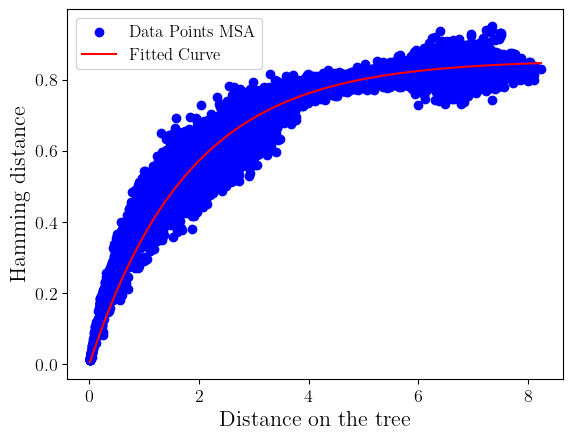

Fitted parameters: a = 0.8553109210194914, mu = 0.5527396554452223. Fitted on 1000 leaves. Fitted curve is d_hamming = 0.8553109210194914 * (1 - exp(-0.5527396554452223 * d_tree))
   ✓ mu = 0.55274

2. Loading sequences and tree...
   ✓ Loaded 15801 leaf sequences

3. Computing site-wise amino acid frequencies...
   ✓ Computed frequencies for 202 sites

4. Computing ancestral state posteriors...
   Using device: cuda
Processing 202 sites with batch_size=64, use_jit=True
Testing JIT compilation...
JIT compilation successful!
Processing batch 1/4
Error in batch 0-64: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
  File "/home/alya/phyloDCA_public/utils/asr_torch_perfect.py", line 153, in felsenstein_batch_jit_core
    
    # Storage for log likelihoods [n_nodes, B, q]
    log_likelihoods = torch.full((n_nodes, B, q), -float('inf'), dtype=dtype, device=device)
                      ~~~~~~~~~~ <--- HERE
    
    # Initializ

In [ ]:
print(f"\nRunning ASR pipeline...")
print(f"  MSA: {msa_file}")
print(f"  Tree: {tree_file}\n")

posteriors, seq_name = run_asr_pipeline(
    msa_file=msa_file,
    tree_file=tree_file,
    output_dir=paths['output_asr']
)

## 🎲 Step 7 — Sample & Rank Candidate Ancestors

Draws candidate ancestor sequences from the ASR posterior, then reshuffles them with DCA-guided MCMC so that residue–residue couplings are respected. Candidates from both sets are ranked by posterior likelihood.

In [ ]:
# Reload helpers in case utils/user_helper_functions.py changed since the kernel started
import importlib
import sys
if 'utils.user_helper_functions' in sys.modules:
    importlib.reload(sys.modules['utils.user_helper_functions'])
from utils.user_helper_functions import sample_and_rank_sequences, save_candidates_to_fasta

candidates, sampled_msa, sampled_msa_original = sample_and_rank_sequences(
    posteriors=posteriors,
    num_samples=NUM_SAMPLES,
    num_top=NUM_TOP_CANDIDATES,
    fields=fields,
    couplings=couplings,
    temperature=MCMC_TEMPERATURE
)

print(f"Top candidates:")
for cand in candidates[:5]:
    source = cand.get('source', '?')
    print(f"  Rank {cand['rank']}: {source:15s} | Score = {cand['score']:.2f}")

## 💾 Step 8 — Save Results to FASTA

Exports the MAP sequence, the consensus sequence, and the top-ranked candidates from both sampling strategies to a single FASTA file.

In [ ]:
output_fasta = f"{paths['output_candidates']}{seq_name}_top_candidates.fasta"

save_candidates_to_fasta(
    candidates=candidates,
    posteriors=posteriors,
    msa_original=sampled_msa_original,
    msa_reshuffled=sampled_msa,
    output_file=output_fasta
)

print(f"\n{'='*60}")
print(f"DONE! Your results are in:")
print(f"  {output_fasta}")
print(f"{'='*60}")

## 🔬 Step 9 (Optional) — Additional Analyses

Two optional, exploratory extras:
- **Gibbs/DCA simulation on a tree** — evolve a chosen root sequence down a tree under the fitted Potts model.
- **Context-dependent entropy (CDE)** — compare how epistatically constrained different sequence ensembles are.

In [ ]:
# -----------------------------------------------------------------------------
# Gibbs DCA sampling on a tree
# -----------------------------------------------------------------------------
# This optional block prompts for a root sequence and a tree, then evolves the
# sequence down the tree with the DCA/Potts Gibbs sampler.

from ete3 import Tree
from utils.samplerOnTrees import mutate_gibbs
from utils.toolsForTreesAndMSAs import amino_acid_seq_to_int, write_MSA_to_fasta
from utils.ci_and_cd_entropy import context_dependent_entropy_msa_torch

root_sequence_str = input("Root sequence as amino-acid string, '-' allowed [Enter = MAP ASR]: ").strip().upper()
if root_sequence_str:
    root_sequence_int = np.array(amino_acid_seq_to_int(root_sequence_str), dtype=int)
else:
    root_sequence_int = np.argmax(posteriors, axis=1).astype(int)

if len(root_sequence_int) != fields.shape[0]:
    raise ValueError(f"Root length {len(root_sequence_int)} does not match DCA length {fields.shape[0]}")

gibbs_tree_file = input(f"Tree file [Enter = {tree_file}]: ").strip() or tree_file
gibbs_mu = float(input("Gibbs DCA mutation rate mu [Enter = 0.5]: ").strip() or 0.5)

tree_gibbs = Tree(gibbs_tree_file)
tree_gibbs.add_features(sequence=root_sequence_int)
mutate_gibbs(tree_gibbs, gibbs_mu, fields, couplings)

gibbs_leaf_msa = np.array([leaf.sequence for leaf in tree_gibbs.iter_leaves()])
gibbs_output_fasta = f"{paths['output_candidates']}{seq_name}_gibbs_dca_leaves.fasta"
write_MSA_to_fasta(gibbs_leaf_msa, gibbs_output_fasta, seq_header="gibbs_dca_leaf")
print(f"✓ Gibbs DCA sampled {gibbs_leaf_msa.shape[0]} leaf sequences")
print(f"✓ Saved Gibbs DCA leaves to: {gibbs_output_fasta}")

In [ ]:
# -----------------------------------------------------------------------------
# Context-dependent entropy (CDE)
# -----------------------------------------------------------------------------
# CDE is reported as the mean context-dependent entropy across sites for each
# sequence. The plot compares any ensembles already available in the notebook.

CDE_MAX_SEQUENCES = 1000
cde_inputs = {}

if 'msa_array' in globals():
    cde_inputs['Natural MSA'] = msa_array[:min(CDE_MAX_SEQUENCES, len(msa_array))]
if 'sampled_msa_original' in globals():
    cde_inputs['ASR posterior samples'] = sampled_msa_original
if 'sampled_msa' in globals():
    cde_inputs['DCA-reshuffled samples'] = sampled_msa
if 'gibbs_leaf_msa' in globals():
    cde_inputs['Gibbs DCA leaves'] = gibbs_leaf_msa

device = 'cuda' if torch.cuda.is_available() else 'cpu'
cde_scores = {
    label: context_dependent_entropy_msa_torch(msa, fields, couplings, device=device)
    for label, msa in cde_inputs.items()
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, scores in cde_scores.items():
    ax.hist(scores, bins=40, density=True, alpha=0.35, label=f"{label} (mean={scores.mean():.2f})")

ax.set_xlabel("Mean context-dependent entropy per sequence")
ax.set_ylabel("Density")
ax.set_title("Context-dependent entropy of sequence ensembles")
ax.legend(frameon=False)
plt.tight_layout()

cde_plot_file = f"{paths['output_candidates']}{seq_name}_cde_distribution.png"
fig.savefig(cde_plot_file, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Saved CDE plot to: {cde_plot_file}")

---

### 🎉 You're done!

Your ranked ancestor candidates are saved in `output_<DATASET_NAME>_candidates/`.

For the full API reference of every helper function used above (and many more), see [`DOCUMENTATION.md`](DOCUMENTATION.md).